In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mpdaf
from mpdaf.obj import Cube, WCS, WaveCoord

In [ ]:
!pip install ppxf
!pip install Powerbin

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from importlib import resources
from urllib import request

from astropy.io import fits
from ppxf.ppxf import ppxf, robust_sigma
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from powerbin import PowerBin
from plotbin.display_bins import display_bins
from plotbin.plot_velfield import plot_velfield
import zipfile

In [ ]:
# 1. Funciones

class read_data_cube:
    """
    Clase para leer el cubo de datos MUSE, corregir por redshift, hacer rebinning logarítmico
    y calcular las coordenadas de cada spaxel.
    """
    def __init__(self, filename, lam_range, redshift):
        self.read_fits_file(filename)

        wave = self.wave / (1 + redshift)
        w = (wave > lam_range[0]) & (wave < lam_range[1])
        wave = wave[w]
        cube = self.cube[w, ...]
        cubevar = self.cubevar[w, ...]

        signal = np.nanmedian(cube, 0)
        noise = np.sqrt(np.nanmedian(cubevar, 0))

        jm = np.argmax(signal)
        row, col = map(np.ravel, np.indices(cube.shape[-2:]))
        # Se usa self.pixsize (definido en read_fits_file)
        x = (col - col[jm]) * self.pixsize
        y = (row - row[jm]) * self.pixsize

        npix = cube.shape[0]
        spectra = cube.reshape(npix, -1)
        variance = cubevar.reshape(npix, -1)

        c = 299792.458
        # Preservar el paso de velocidad más pequeño
        velscale = np.min(c * np.diff(np.log(wave)))

        lam_range_temp_rebin = [np.min(wave), np.max(wave)]

        spectra, ln_lam_gal, velscale = util.log_rebin(lam_range_temp_rebin, spectra, velscale=velscale)
        variance, _, _ = util.log_rebin(lam_range_temp_rebin, variance, velscale=velscale)

        self.spectra = spectra
        self.variance = variance
        self.x = x
        self.y = y
        self.signal = signal.ravel()
        self.noise = noise.ravel()
        self.col = col + 1
        self.row = row + 1
        self.velscale = velscale
        self.ln_lam_gal = ln_lam_gal
        # Se usa self.fwhm_gal (definido en read_fits_file)
        self.fwhm_gal = self.fwhm_gal / (1 + redshift)

    def read_fits_file(self, filename):
        with fits.open(filename, memmap=False) as hdu:
            head = hdu['DATA'].header

            print("Cargando el cubo de datos completo. Esto puede requerir mucha memoria.")
            cube = hdu['DATA'].data
            variance = hdu['STAT'].data

            wave = head['CRVAL3'] + head['CD3_3'] * np.arange(cube.shape[0])

        self.cube = cube
        self.cubevar = variance
        self.wave = wave
        self.fwhm_gal = 2.62 # FWHM instrumental de MUSE (aprox)
        self.pixsize = abs(head["CD1_1"]) * 3600 # Tamaño del píxel en arcsec
        self.header = head                 # Guardamos el header
        self.ny = self.cube.shape[1]       # Dimensión Y original
        self.nx = self.cube.shape[2]       # Dimensión X original


def clip_outliers(galaxy, bestfit, mask):
    """
    Repite el ajuste después de recortar los bins que se desvían más de 3*sigma.
    """
    while True:
        scale = galaxy[mask] @ bestfit[mask]/np.sum(bestfit[mask]**2)
        resid = scale*bestfit[mask] - galaxy[mask]
        err = robust_sigma(resid, zero=1)
        ok_old = mask
        mask = np.abs(bestfit - galaxy) < 3*err
        if np.array_equal(mask, ok_old):
            break
    return mask

def ppxf_fit_and_clean(templates, galaxy, noise, velscale, start, mask0, lam, lam_temp, plot=True, quiet=False, **kwargs):
    """
    Wrapper de pPXF que realiza dos pasadas. La primera estima el ruido y
    la segunda excluye los outliers.
    Acepta argumentos de múltiples componentes (**kwargs).
    """
    mask = mask0.copy()

    # Primera pasada: ajuste inicial
    pp = ppxf(templates, galaxy, noise, velscale, start,
              lam=lam, lam_temp=lam_temp,
              mask=mask, quiet=quiet, **kwargs) # Pasa los kwargs

    if plot:
        plt.figure(figsize=(15, 4))
        plt.subplot(121)
        pp.plot()
        plt.title("Ajuste inicial (antes de quitar outliers)")

    # Limpiar outliers
    mask = clip_outliers(galaxy, pp.bestfit, mask)
    mask &= mask0  # Asegurarse de que los píxeles enmascarados originalmente sigan enmascarados

    # Segunda pasada: ajuste final con la máscara limpia
    pp = ppxf(templates, galaxy, noise, velscale, start,
              lam=lam, lam_temp=lam_temp,
              mask=mask, quiet=quiet, **kwargs) # Pasa los kwargs de nuevo

    pp.optimal_template = templates.reshape(templates.shape[0], -1) @ pp.weights
    resid = (pp.galaxy - pp.bestfit)[pp.goodpixels]
    pp.sn = np.nanmedian(pp.galaxy[pp.goodpixels])/robust_sigma(resid)

    if plot:
        plt.subplot(122)
        pp.plot()
        plt.title(f"Ajuste final (S/N={pp.sn:.1f})")

    return pp



In [ ]:
# Definir S/N objetivo (de la Celda 8 original)
target_sn = 60
redshift = 0.005457 #NGC1365
# Rango para la galaxia (el espectro que se va a ajustar)
lam_range_gal = [4770, 6800]
# Rango más ancho para los templates para evitar el AssertionError (padding)
lam_range_temp_sps = [4500, 7000]

In [ ]:
# 2.  Datos

# Definir la ruta del archivo (de la Celda 2 original)
path = '/content/drive/MyDrive/Investigacion/FITS_MUSE/recorteNGC5643(5000_6500).fits'



In [ ]:
s = read_data_cube(Path(path), lam_range_gal, redshift)

Cargando el cubo de datos completo. Esto puede requerir mucha memoria.


In [ ]:
s_filt = np.nan_to_num(s,nan=0)
lam_gal_orig = np.exp(s_filt.ln_lam_gal) # Grid de longitud de onda original de la galaxia


Iniciando PowerBin para agrupar spaxels...
Bin-accretion Delaunay...
2708  initial bins.
1939  good bins.
Regularization...
Bins: 1939; Single Pixels: 148/102399
Capacity Fractional RMS Scatter (%): 6.62
Time Accretion: 11.20 s
Time Regularization (it=49): 4.08 s
Se crearon 1939 bins.
Número de ejes en la figura: 2


/tmp/ipykernel_2316/2793776992.py:33: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=3)   # aumentá/disminuí este valor a gusto


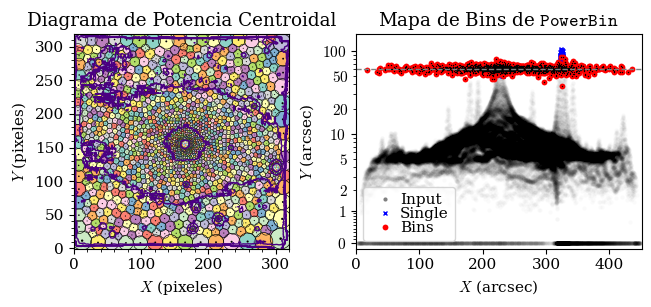

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 11,
})

print("Iniciando PowerBin para agrupar spaxels...")
xy = np.column_stack([s.x, s.y])
pow = PowerBin(xy, fun_capacity, target_sn)
bin_num = pow.bin_num
nbins = np.unique(bin_num).size
print(f"Se crearon {nbins} bins.")

pow.plot(ylabel='S/N')

fig = plt.gcf()
print(f"Número de ejes en la figura: {len(fig.axes)}")  # para verificar índices

# --- Panel izquierdo: Diagrama de Potencia Centroidal (píxeles) ---
ax_diag = fig.axes[0]
ax_diag.set_title(r"Diagrama de Potencia Centroidal")
ax_diag.set_xlabel(r"$X$ (pixeles)")
ax_diag.set_ylabel(r"$Y$ (pixeles)")

# --- Panel derecho: Mapa de Bins (arcsec) ---
ax_bins = fig.axes[1]
ax_bins.set_title(r"Mapa de Bins de $\mathtt{PowerBin}$")
ax_bins.set_xlabel(r"$X$ (arcsec)")
ax_bins.set_ylabel(r"$Y$ (arcsec)")

# --- Separación entre subplots ---
fig.subplots_adjust(wspace=3)   # aumentá/disminuí este valor a gusto
# alternativa: fig.tight_layout(w_pad=3)
plt.savefig('/content/drive/MyDrive/Tesis/NGC5643_powerbin.png', dpi=600)
plt.show()

In [ ]:
#Templates

sps_name = 'galaxev'
FWHM_gal = None

ppxf_dir = resources.files('ppxf')
basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename

if not filename.is_file():
    print(f"Descargando {basename}...")
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)

# Usar el rango ANCHO (`lam_range_temp_sps`) para los modelos estelares
sps = lib.sps_lib(filename, s.velscale, FWHM_gal, norm_range=[5100, 5400], lam_range=lam_range_temp_sps)
ln_lam_temp = sps.ln_lam_temp # Grid logarítmico de los templates
lam_temp_lin = np.exp(ln_lam_temp) # Grid lineal de los templates

# Separar en poblaciones joven y vieja
templates_all = sps.templates.reshape(sps.templates.shape[0], -1)
age_grid = sps.age_grid.ravel()         # en Gyr
metal_grid = sps.metal_grid.ravel()

# Identificar templates viejos (> 1 Gyr)
old_idx = age_grid > 0.001
templates_old = templates_all[:, old_idx]
age_grid_old = age_grid[old_idx]
metal_grid_old = metal_grid[old_idx]

# Identificar templates jóvenes (<= 1 Gyr)
young_idx = age_grid <= 0.001
templates_young = templates_all[:, young_idx]
age_grid_young = age_grid[young_idx]
metal_grid_young = metal_grid[young_idx]



# Líneas de Gas (generadas en el grid de la galaxia original)
gas_fwhm = s.fwhm_gal
gas_templates_orig, gas_names, line_wave = util.emission_lines(
    s.ln_lam_gal, lam_range_gal, gas_fwhm, tie_balmer=False
)

# Resamplear el gas al grid de los modelos estelares (el grid más ancho)
gas_templates = np.array([np.interp(ln_lam_temp, s.ln_lam_gal, gas_spec) for gas_spec in gas_templates_orig.T]).T

# Combinación final de templates
templates = np.hstack([templates_old, templates_young, gas_templates])

# Componentes en array
component = np.array(
    [0]*templates_old.shape[1] +
    [1]*templates_young.shape[1] +
    [2]*gas_templates.shape[1],
    dtype=int
)
gas_component = component == 2

start = [[0, 200], [0, 100], [0, 100]] # V, sigma para [vieja, joven, gas]

# Tied
tied = [['', ''],           # Componente 0 (vieja): p[0], p[1] (libres)
        ['p[0]', 'p[1]'],   # Componente 1 (joven): atada a p[0] y p[1]
        ['', '']]           # Componente 2 (gas): p[4], p[5] (libres)

# Mascara
mask_gal = util.determine_mask(s.ln_lam_gal, lam_range_gal, redshift=redshift, width=800)

vel_s, sig_s, vel_g, sig_g, ebv = np.zeros((5, nbins))
age_young_mean, met_young_mean, age_old_mean, met_old_mean = np.zeros((4, nbins))
gas_fluxes = np.zeros((nbins, len(gas_names)))
frac_young = np.full(nbins, np.nan)
age_all_mean = np.full(nbins, np.nan)  # edad luminosa promedio (todas las plantillas)


Emission lines included in gas templates:
['Hbeta' 'Halpha' '[SII]6716' '[SII]6731' 'HeI5876' '[OIII]5007_d'
 '[OI]6300_d' '[NII]6583_d']


In [ ]:
# --- Lista para guardar los resultados ---
all_bin_results = []

#Para guardar los espectros
residual_spectra = np.zeros_like(s.spectra)

# --- PASADA 1: Ajustar todos los bins SIN PLOT ---
print(f"--- INICIANDO PASADA 1: Ajustando todos los {nbins} bins (sin gráficos) ---")
for j in range(nbins):
    plot = False
    quiet = True

    print(f"Analizando Bin {j+1}/{nbins}...", end="\r")
    w = bin_num == j

    galaxy = np.nanmean(s.spectra[:, w], 1)
    variance_bin = np.nanmean(s.variance[:, w], 1)
    num_spaxels = np.sum(w)
    noise = np.sqrt(variance_bin / num_spaxels) if num_spaxels > 0 else np.full_like(galaxy, np.inf)

    if not np.all(np.isfinite(noise)):
        if not np.any(np.isfinite(noise)):
            noise = np.full_like(noise, 1e6)
        else:
            noise[~np.isfinite(noise)] = np.nanmax(noise[np.isfinite(noise)]) * 100
    if np.nanmax(noise) <= 0:
        noise = np.full_like(noise, 1.0)

    pp = ppxf_fit_and_clean(templates, galaxy, noise, s.velscale, start,
                            mask_gal,
                            lam_gal_orig,
                            lam_temp_lin,
                            plot=plot, quiet=quiet,
                            moments=[2, 2, 2], degree=-1, mdegree=4,
                            component=component, gas_component=gas_component,
                            gas_names=gas_names, reddening=0.1, tied=tied)

    # Guardar el resultado del bin
    all_bin_results.append((pp.chi2, j))

    # Guardar los datos para los mapas
    vel_s[j], sig_s[j] = pp.sol[0]
    vel_g[j], sig_g[j] = pp.sol[2]
    ebv[j] = pp.reddening if pp.reddening is not None else 0

    # Máscara y peso de las edades
    weights = pp.weights
    wo = weights[component == 0]  # viejas
    wy = weights[component == 1]  # jóvenes
    tot = wo.sum() + wy.sum()
    frac_young[j] = wy.sum()/tot if tot > 0 else np.nan

    # Edades como ⟨log10(edad/yr)⟩ con resguardo de suma de pesos
    age_old_mean[j]   = (np.log10(age_grid_old*1e9)   @ wo)/wo.sum() if wo.sum() > 0 else np.nan
    age_young_mean[j] = (np.log10(age_grid_young*1e9) @ wy)/wy.sum() if wy.sum() > 0 else np.nan

    # Metalicidades promedio ponderadas
    met_old_mean[j]   = (metal_grid_old   @ wo)/wo.sum() if wo.sum() > 0 else np.nan
    met_young_mean[j] = (metal_grid_young @ wy)/wy.sum() if wy.sum() > 0 else np.nan
    w_sum = wo.sum() + wy.sum()
    if w_sum > 0:
        logAge_all = ((np.log10(age_grid_old*1e9)   @ wo) +
                      (np.log10(age_grid_young*1e9) @ wy)) / w_sum
        age_all_mean[j] = logAge_all
    else:
        age_all_mean[j] = np.nan
    gas_fluxes[j, :] = pp.gas_flux

    #Separamos la componente estelar
    if hasattr(pp, 'gas_bestfit') and pp.gas_bestfit is not None:
        stellar_fit = pp.bestfit - pp.gas_bestfit
    else:
        stellar_fit = pp.bestfit

    #Espectro bruto - componente estelar
    residual_spectra[:, w] = s.spectra[:, w] - stellar_fit[:, None]

print(f"\nAnálisis de los {nbins} bins completado.")

#Se suman todos los espectros y se 'aplastan en 1 solo eje
residual_1d_final = np.nansum(residual_spectra, axis=1)


--- INICIANDO PASADA 1: Ajustando todos los 3438 bins (sin gráficos) ---

Análisis de los 3438 bins completado.


In [ ]:

print("\n--- Guardando todos los parámetros y matrices de pPXF ---")

# ¡IMPORTANTE! Usa la ruta directa a tu Google Drive para no perderlo
ruta_drive = "/content/drive/MyDrive/Tesis/" # Ajusta esto a tu carpeta
nombre_archivo_npz = os.path.join(ruta_drive, "resultados_completos_ppxf_n1365.npz")
nombre_archivo_fits = os.path.join(ruta_drive, "cubo_residual_ppxf_n1365.fits")

try:
    # Guardamos absolutamente todas las variables útiles
    np.savez_compressed(
        nombre_archivo_npz,
        # Matrices pesadas
        residual_spectra=residual_spectra,
        residual_1d_final=residual_1d_final,
        lam_gal_orig=lam_gal_orig,

        # Cinemática
        vel_s=vel_s, sig_s=sig_s,
        vel_g=vel_g, sig_g=sig_g,

        # Poblaciones estelares y extinción
        ebv=ebv,
        age_young_mean=age_young_mean, met_young_mean=met_young_mean,
        age_old_mean=age_old_mean, met_old_mean=met_old_mean,
        frac_young=frac_young, age_all_mean=age_all_mean,

        # Gas y Bins
        gas_fluxes=gas_fluxes,
        bin_num=bin_num
    )
    print(f"¡Éxito! Todos los arrays guardados en: {nombre_archivo_npz}")
except Exception as e:
    print(f"Error al guardar los resultados .npz: {e}")

# =====================================================================
# 2. GUARDAR EL CUBO FITS ESPACIAL
# =====================================================================
try:
    n_wave = residual_spectra.shape[0]
    ny = s.ny
    nx = s.nx

    residual_cube_3d = residual_spectra.reshape(n_wave, ny, nx)

    hdu_primary = fits.PrimaryHDU()
    hdu_image = fits.ImageHDU(data=residual_cube_3d, header=s.header, name='RESIDUAL_GAS')

    hdul = fits.HDUList([hdu_primary, hdu_image])
    hdul.writeto(nombre_archivo_fits, overwrite=True)

    print(f"¡Éxito! Cubo FITS guardado en: {nombre_archivo_fits}")
except Exception as e:
    print(f"Error al guardar el archivo FITS: {e}")


--- Guardando todos los parámetros y matrices de pPXF ---
¡Éxito! Todos los arrays guardados en: /content/drive/MyDrive/Tesis/resultados_completos_ppxf_n1365.npz
¡Éxito! Cubo FITS guardado en: /content/drive/MyDrive/Tesis/cubo_residual_ppxf_n1365.fits


'\nSi mañana se te reinicia Colab, SOLO tienes que montar tu Drive, importar \nnumpy y correr esto (NO corras el loop de ppxf de 5 horas):\n\nimport numpy as np\n\nruta_drive = "/content/drive/MyDrive/Investigacion/"\ndatos = np.load(ruta_drive + "resultados_completos_ppxf_n2992.npz")\n\n# Extraer las variables de vuelta al entorno\nresidual_spectra = datos[\'residual_spectra\']\nresidual_1d_final = datos[\'residual_1d_final\']\nlam_gal_orig = datos[\'lam_gal_orig\']\n\nvel_s = datos[\'vel_s\']\nsig_s = datos[\'sig_s\']\nvel_g = datos[\'vel_g\']\nsig_g = datos[\'sig_g\']\nebv = datos[\'ebv\']\n\nage_young_mean = datos[\'age_young_mean\']\nmet_young_mean = datos[\'met_young_mean\']\nage_old_mean = datos[\'age_old_mean\']\nmet_old_mean = datos[\'met_old_mean\']\nfrac_young = datos[\'frac_young\']\nage_all_mean = datos[\'age_all_mean\']\n\ngas_fluxes = datos[\'gas_fluxes\']\nbin_num = datos[\'bin_num\']\n\nprint("¡Datos cargados en segundos!")\n# Ahora ya puedes correr tus celdas para hac

In [ ]:

ruta_drive = "/content/drive/MyDrive/Tesis/"
datos = np.load(ruta_drive + "resultados_completos_ppxf_n1365.npz")

# Extraer las variables de vuelta al entorno
residual_spectra = datos['residual_spectra']
residual_1d_final = datos['residual_1d_final']
lam_gal_orig = datos['lam_gal_orig']

vel_s = datos['vel_s']
sig_s = datos['sig_s']
vel_g = datos['vel_g']
sig_g = datos['sig_g']
ebv = datos['ebv']

age_young_mean = datos['age_young_mean']
met_young_mean = datos['met_young_mean']
age_old_mean = datos['age_old_mean']
met_old_mean = datos['met_old_mean']
frac_young = datos['frac_young']
age_all_mean = datos['age_all_mean']

gas_fluxes = datos['gas_fluxes']
bin_num = datos['bin_num']

print("¡Datos cargados en segundos!")
# Ahora ya puedes correr tus celdas para hacer gráficos o mapas.

¡Datos cargados en segundos!


In [ ]:
cube = Cube(path)

spec = cube.sum(axis=(1, 2))

In [ ]:
print(cube.unit)

1e-20 erg / (Angstrom s cm2)


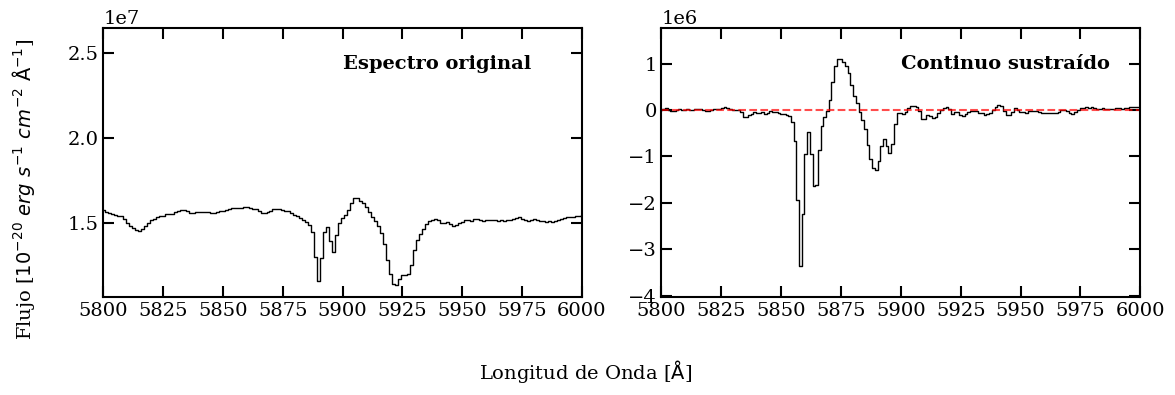

In [ ]:
plt.rcParams.update({
    'font.family': 'serif',          # Fuente estilo artículo científico
    'font.size': 14,                 # Tamaño de letra base
    'axes.linewidth': 1.5,           # Grosor de la caja del gráfico
    'xtick.major.size': 8,           # Largo de las marcas (ticks) en X
    'xtick.major.width': 1.5,        # Grosor de las marcas en X
    'ytick.major.size': 8,           # Largo de las marcas en Y
    'ytick.major.width': 1.5,        # Grosor de las marcas en Y
    'xtick.minor.size': 4,           # Largo de marcas menores
    'xtick.minor.width': 1.0,
    'ytick.minor.size': 4,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',         # Ticks apuntando hacia adentro
    'ytick.direction': 'in',
    'xtick.top': True,               # Ticks en la parte superior
    'ytick.right': True              # Ticks en la parte derecha
})

# ==========================================
# 2. CREACIÓN DE LA FIGURA
# ==========================================
# Creamos una figura con 2 subgráficos (uno arriba del otro)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

# --- PANEL SUPERIOR: ESPECTRO COMPLETO ---
ax1.plot(spec.wave.coord(), spec.data, color='black', linewidth=1.0, drawstyle='steps-mid')
# ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7) # Línea base cero


# ax1.set_ylabel(r'Flujo [$10^{-20} \ erg \ s^{-1} \ cm^{-2} \ \mathrm{\AA}^{-1}$] ', fontsize = 12)
# ax1.set_xlim(5800, 6000)
ax1.text(0.5, 0.90, 'Espectro original', transform=ax1.transAxes,
         fontsize=14, fontweight='bold', va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# --- PANEL INFERIOR: ZOOM (5600 - 6200 Å) ---
# Aquí seguramente tienes el doblete de Na I D (5890, 5896 Å) y He I
ax2.plot(lam_gal_orig, residual_1d_final, color='black', linewidth=1.0, drawstyle='steps-mid')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# ax2.set_xlabel(r'Longitud de Onda [$\mathrm{\AA}$]')
# ax2.set_ylabel(r'Flujo [$10^{-20} \ erg \ s^{-1} \ cm^{-2} \ \mathrm{\AA}^{-1}$] ', fontsize = 12)
# ax2.set_xlim(5800, 6000)
ax2.text(0.5, 0.90, r'Continuo sustraído', transform=ax2.transAxes,
         fontsize=14, fontweight='bold', va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Ajuste automático del eje Y para la región del zoom
mask_zoom = (lam_gal_orig >= 5600) & (lam_gal_orig <= 6200)
if np.any(mask_zoom):
    y_min = np.nanmin(residual_1d_final[mask_zoom])
    y_max = np.nanmax(residual_1d_final[mask_zoom])
    padding = (y_max - y_min) * 0.15 # 15% de margen arriba y abajo
    ax2.set_ylim(y_min - padding, y_max + padding)

fig.supylabel(r'Flujo [$10^{-20} \ erg \ s^{-1} \ cm^{-2} \ \mathrm{\AA}^{-1}$] ', fontsize = 14)
fig.supxlabel(r'Longitud de Onda [$\mathrm{\AA}$]', fontsize=14)
# ==========================================
# 3. GUARDAR Y MOSTRAR
# ==========================================
plt.tight_layout() # Ajusta los márgenes para que no se superpongan las etiquetas

# Descomenta la siguiente línea si quieres guardar el gráfico en alta resolución (PDF es ideal para papers)
plt.savefig('/content/drive/MyDrive/Tesis/NGC1365_ppxfplano.png', dpi=600, bbox_inches='tight')

plt.show()